# Gene expression clustering

**Goal:**
Cluster gene expression. Identify clusters of genes with similar profiles of activation or repression.

**Simple Procedure:**
1. Align peaks of gene expression
2. Then cluster.
3. Visualize expression of clusters to identify patterns of similar activation.
4. Visualize the chromatin of the activation, and repression timepoints.

**More complex**
1. Compute a distance matrix
2. For every pair of entries, compute a correlation score by sliding the vector down each timepoint. The value of the distance will be the translation the outcome the maximal correlation.

**Expected outcome:**
There may be some similar patterns among similarly activated genes. For example, a gene that rapidly activates may exhibit a stronger change in nucleosome shift than a gene that gradually turns on.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.gene_clustering import GeneClustering

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'

gene_clustering = GeneClustering(outdir)

Selected 558 genes in the top 80% with quantile value greater than 1.19


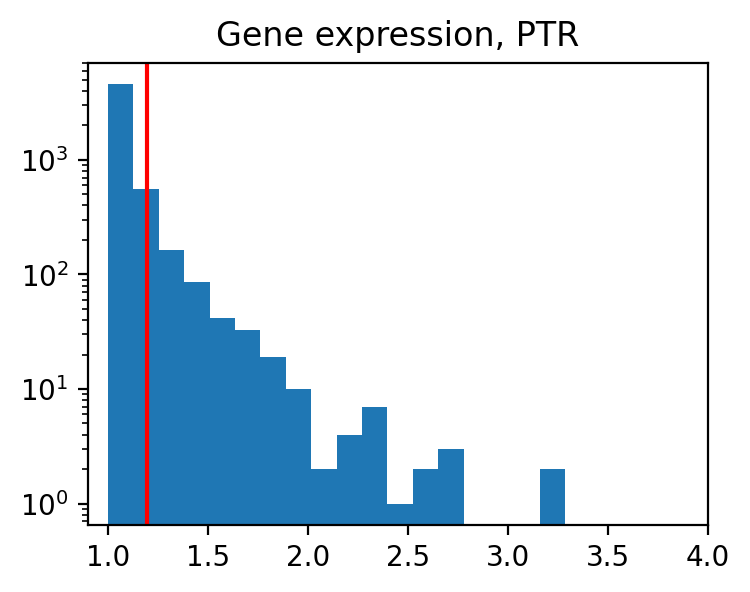

In [374]:
gene_clustering.set_threshold_ptr(0.9)
# Change from 0.9

In [208]:
distance_matrix = gene_clustering.compute_distance_from_gene_expression()

0/558 - 00:00:00.258
100/558 - 00:00:21.931
200/558 - 00:00:38.902
300/558 - 00:00:51.694
400/558 - 00:01:00.297
500/558 - 00:01:04.745
00:01:05.416


In [209]:
from src.timer import Timer

# Compute a elbow curve of the inertia (sum of distances) to identify critical values of k
timer = Timer()

k_values = np.arange(2, 48, 1)
inertias = []

go_results_all = pd.DataFrame()
go_results_sigfig_all = pd.DataFrame()

for k in k_values:

    print(f"k={k}", end=', ')
    gene_clustering.cluster_expression(k)
    inertia = gene_clustering.kmedoids.inertia_
    inertias.append(inertia)
    print(f"    inertia={inertia:.2f}", end=', ')


k=2,     inertia=65.89, k=3,     inertia=58.59, k=4,     inertia=52.39, k=5,     inertia=43.90, k=6,     inertia=43.71, k=7,     inertia=36.21, k=8,     inertia=32.50, k=9,     inertia=29.88, k=10,     inertia=29.51, k=11,     inertia=27.81, k=12,     inertia=25.94, k=13,     inertia=23.88, k=14,     inertia=22.93, k=15,     inertia=22.84, k=16,     inertia=22.62, k=17,     inertia=20.58, k=18,     inertia=19.98, k=19,     inertia=18.87, k=20,     inertia=18.73, k=21,     inertia=18.16, k=22,     inertia=17.24, k=23,     inertia=17.16, k=24,     inertia=16.49, k=25,     inertia=15.27, k=26,     inertia=15.68, k=27,     inertia=15.43, k=28,     inertia=15.42, k=29,     inertia=14.05, k=30,     inertia=13.54, k=31,     inertia=13.52, k=32,     inertia=13.89, k=33,     inertia=12.36, k=34,     inertia=12.66, k=35,     inertia=12.05, k=36,     inertia=12.25, k=37,     inertia=11.69, k=38,     inertia=11.78, k=39,     inertia=11.20, k=40,     inertia=11.29, k=41,     inertia=10.68, k=42,   

Text(0, 0.5, 'Inertia, sum of distances')

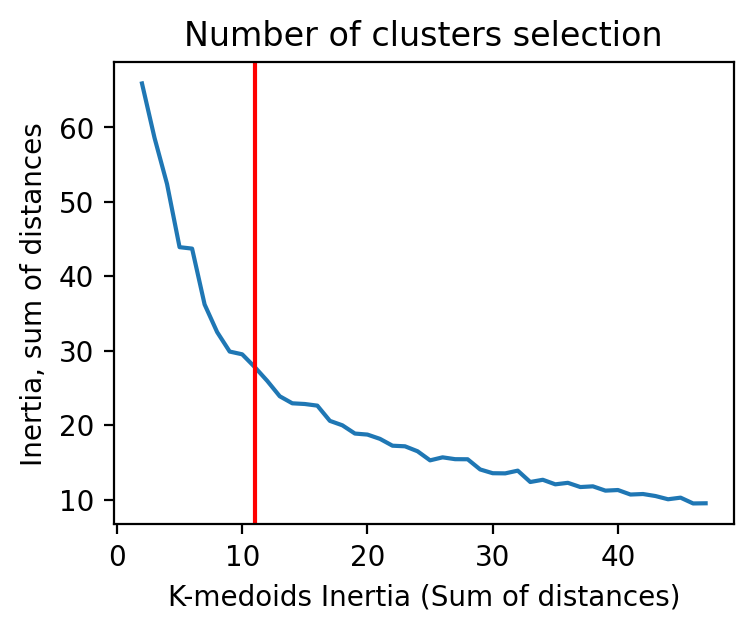

In [373]:
plt.figure(figsize=(4, 3))
plt.plot(k_values, inertias)
plt.axvline(11, c='red')
plt.xlabel("K-medoids Inertia (Sum of distances)")
plt.title("Number of clusters selection")
plt.ylabel("Inertia, sum of distances")


In [302]:
gene_clustering.cluster_expression(11)
gene_clustering.compute_medoids()
gene_clustering.compute_alignments_and_interesting_points_per_cluster()

In [447]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

plot_dir = (f'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/clustering/')

for cluster in range(1, gene_clustering.num_clusters+1):
    fig = plt.figure(figsize=(5, 3))
    gene_clustering.plot_aligned_cluster(cluster)
    save_figure_for_paper(f'{plot_dir}/expression_curves_cluster{cluster}.png')
    plt.close(fig)


In [1017]:
Hpos_tp_top_map = gene_clustering.config.H_map_df
Hpos_tp_top_map = Hpos_tp_top_map[Hpos_tp_top_map.phase != 'DG1']

In [796]:
gene_clustering.run_gene_ontology_on_clustered_genes(gene_clustering.clustered_expression)

data/go.obo: fmt(1.2) rel(2018-08-29) 47,313 Terms


In [797]:
gene_clustering.print_go_results()

Cluster 1
  Microtubule nucleation
  Structural constituent of cytoskeleton
  Inner plaque of spindle pole body

Cluster 2
  Sulfate assimilation
  Methionine metabolic process

Cluster 4
  MCM complex
  Nuclear pre-replicative complex
  Pre-replicative complex assembly involved in nuclear cell cycle DNA replication
  Mitotic S phase
  DNA replication preinitiation complex
  DNA replication origin binding
  DNA strand elongation involved in DNA replication
  Replication fork protection complex
  Double-strand break repair via break-induced replication
  DNA replication initiation
  Chromatin binding
  Four-way junction helicase activity
  Single-stranded DNA-dependent ATPase activity
  Extracellular region
  DNA unwinding involved in DNA replication
  Single-stranded DNA binding
  ATP-dependent 3'-5' DNA helicase activity

Cluster 6
  Nuclear nucleosome
  Chromatin assembly or disassembly
  Spindle pole body
  DNA binding

Cluster 8
  Mitotic sister chromatid cohesion
  Replication for

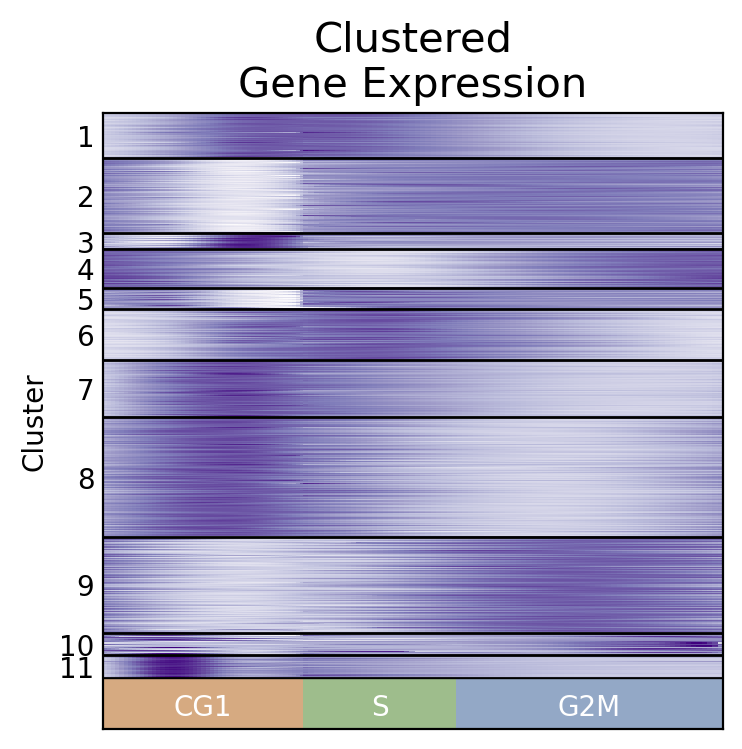

In [1004]:
gene_clustering.plot_clustered_heatmap()
save_figure_for_paper(f'{plot_dir}/cluster_heatmap.png')


In [445]:
for i in range(gene_clustering.num_clusters):

    selected_cluster = i+1
    print(f"Cluster {selected_cluster}")
    chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
    gene_clustering.load_chromatin_for_cluster(chromatin_dir, selected_cluster)
    gene_clustering.shift_cluster_chromatin_data()
    fig = gene_clustering.plot_chromatin_in_cluster()
    save_path = (f'{plot_dir}/chromatin_'
                 f'{selected_cluster}.png')
    plt.savefig(save_path, dpi=150)
    plt.close(fig)


Cluster 1
Shape of the loaded F: (178, 2093)
(178, 2093)
1/44 - 00:00:00.027
Cluster 2
Shape of the loaded F: (178, 2093)
(178, 2093)
1/74 - 00:00:00.035
Cluster 3
Shape of the loaded F: (178, 2093)
(178, 2093)
1/16 - 00:00:00.009
Cluster 4
Shape of the loaded F: (178, 2093)
(178, 2093)
1/39 - 00:00:00.025
Cluster 5
Shape of the loaded F: (178, 2093)
(178, 2093)
1/20 - 00:00:00.016
Cluster 6
Shape of the loaded F: (178, 2093)
(178, 2093)
1/51 - 00:00:00.026
Cluster 7
Shape of the loaded F: (178, 2093)
(178, 2093)
1/56 - 00:00:00.026
Cluster 8
Shape of the loaded F: (178, 2093)
(178, 2093)
1/118 - 00:00:00.034
Cluster 9
Shape of the loaded F: (178, 2093)
(178, 2093)
1/95 - 00:00:00.034
Cluster 10
Shape of the loaded F: (178, 2093)
(178, 2093)
1/22 - 00:00:00.013
Cluster 11
Shape of the loaded F: (178, 2093)
(178, 2093)
1/23 - 00:00:00.015


Cluster 4
Shape of the loaded F: (178, 2093)
(178, 2093)
1/39 - 00:00:00.026


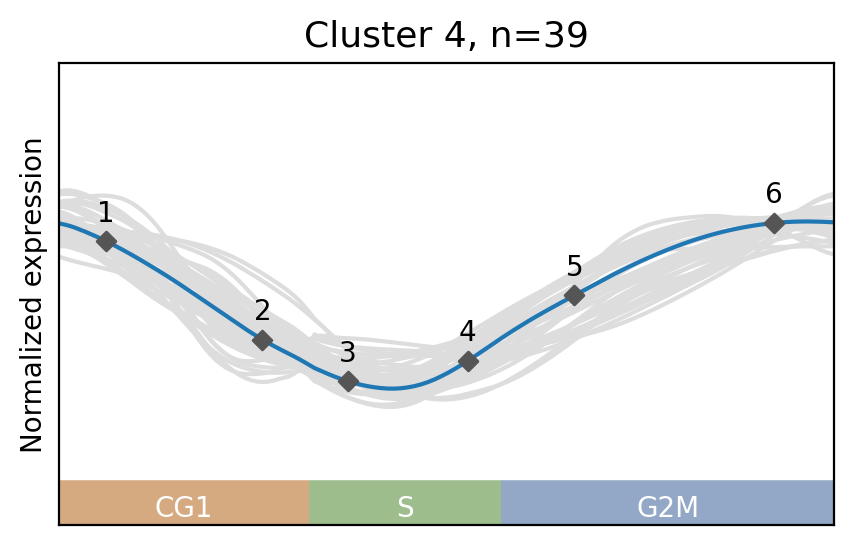

In [1096]:
from src.helpers import proportion_indices

fig = plt.figure(figsize=(5, 3))

g1_indices = config.get_Hpositions_for_phase('CG1')
s_indices = config.get_Hpositions_for_phase('S')
g2m_indices = config.get_Hpositions_for_phase('G2M')

sel_g1_indices = proportion_indices(g1_indices, [0.2, 0.8])
sel_s_indices = proportion_indices(s_indices, [0.2, 0.8])
sel_g2m_indices = proportion_indices(g2m_indices, [0.2, 0.8])

phase_indices = np.concatenate([
    sel_g1_indices,
    sel_s_indices,
    sel_g2m_indices
])

gene_clustering.plot_aligned_cluster(4, plot_marker_xs=phase_indices)

In [ ]:
selected_cluster = 4
print(f"Cluster {selected_cluster}")
chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
gene_clustering.load_chromatin_for_cluster(chromatin_dir, selected_cluster)
gene_clustering.shift_cluster_chromatin_data()

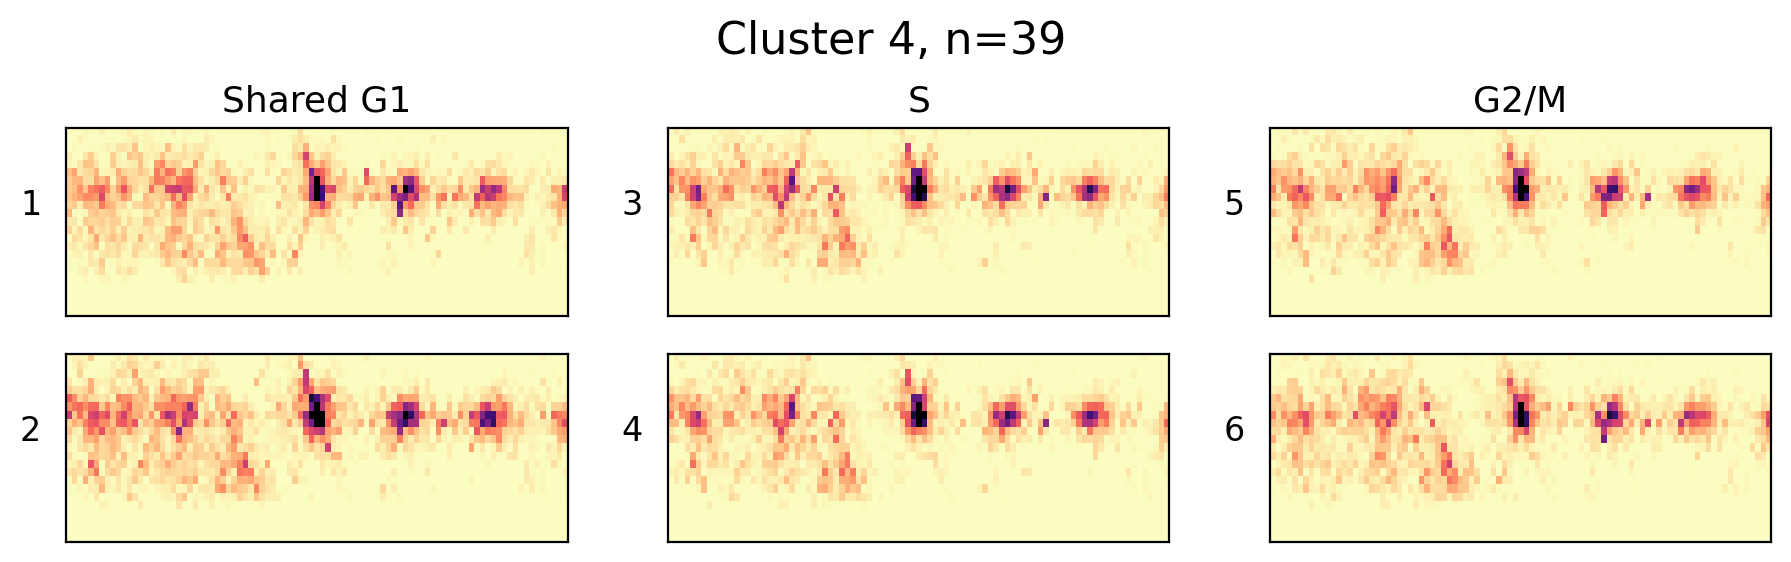

In [1097]:
fig = gene_clustering.plot_chromatin_in_cluster(full=False, 
    plot_h_positions=phase_indices)